# Task 5: Sales Prediction Using Python

Dataset: Advertising.csv (TV, Radio, Newspaper spend -> Sales)

Goal: Predict product sales based on advertising spend across TV, Radio, and Newspaper channels.

## Step 1: Load the Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Advertising.csv')
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [2]:
# This version of the dataset has clean columns already: TV, radio, newspaper, sales
df.columns

Index(['TV', 'radio', 'newspaper', 'sales'], dtype='str')

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   radio      200 non-null    float64
 2   newspaper  200 non-null    float64
 3   sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


## Step 2: EDA - Null Check and Descriptive Statistics

In [4]:
df.isnull().sum()

TV           0
radio        0
newspaper    0
sales        0
dtype: int64

In [5]:
df = df.dropna()
df = df.drop_duplicates()
df.describe()

,TV,radio,newspaper,sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


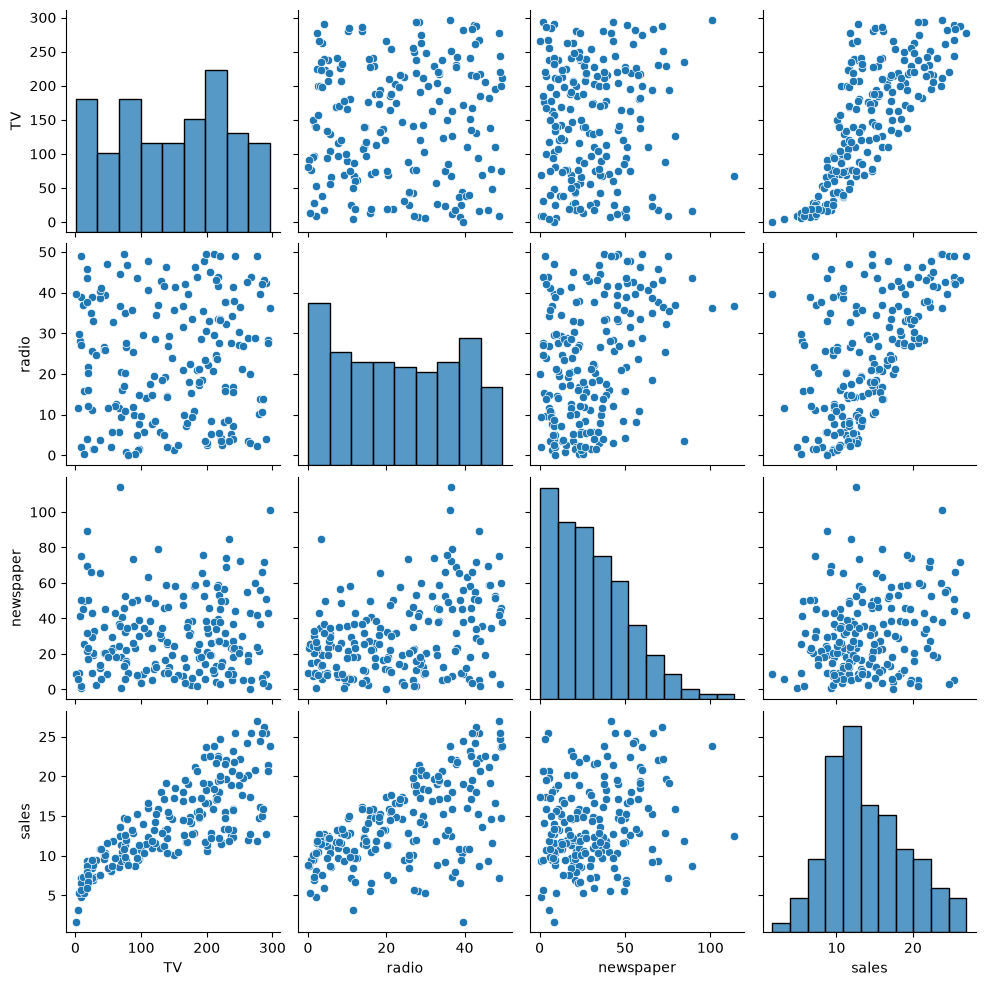

In [6]:
sns.pairplot(df)
plt.show()

## Step 3: Individual Scatter Plots - Sales vs Each Channel

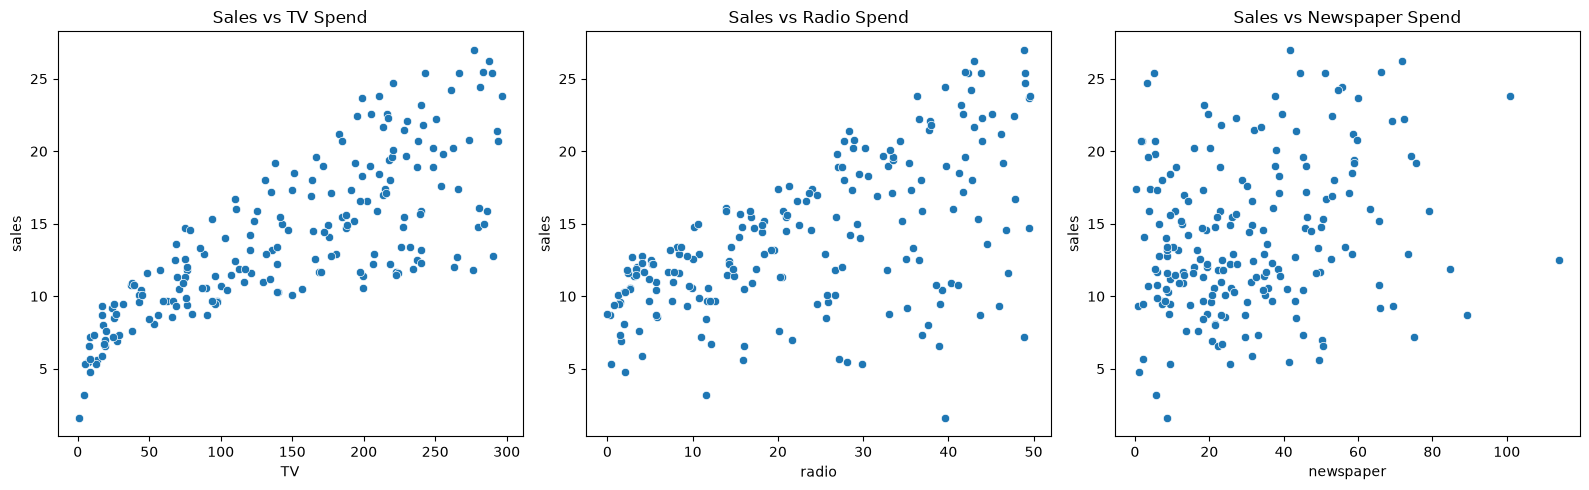

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16,5))

sns.scatterplot(data=df, x='TV', y='sales', ax=axes[0])
axes[0].set_title('Sales vs TV Spend')

sns.scatterplot(data=df, x='radio', y='sales', ax=axes[1])
axes[1].set_title('Sales vs Radio Spend')

sns.scatterplot(data=df, x='newspaper', y='sales', ax=axes[2])
axes[2].set_title('Sales vs Newspaper Spend')

plt.tight_layout()
plt.show()

**Observation:** Note visually which channel shows the strongest, most linear relationship with Sales - this is often TV, with Radio showing a moderate relationship and Newspaper showing a weak or noisy relationship. We'll confirm this numerically with the correlation matrix and later with model coefficients.

## Step 4: Correlation Matrix Heatmap

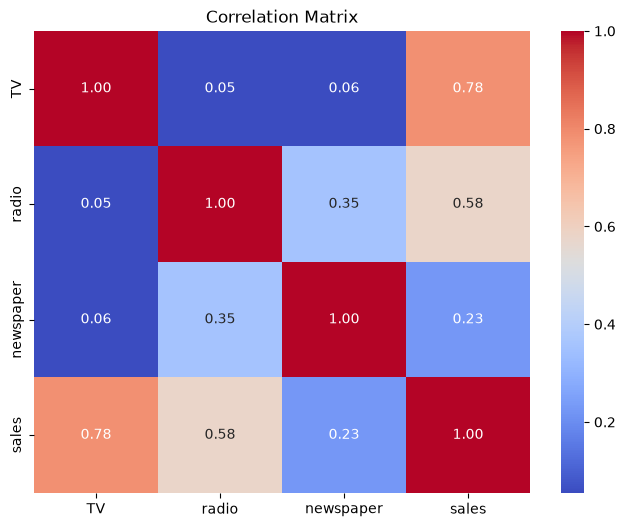

sales        1.000000
TV           0.782224
radio        0.576223
newspaper    0.228299
Name: sales, dtype: float64

In [8]:
plt.figure(figsize=(8,6))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

corr['sales'].sort_values(ascending=False)

## Step 5: Train/Test Split

In [9]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['sales'])
y = df['sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(160, 3) (40, 3)


## Step 6: Train Models - Linear Regression (baseline) + Random Forest

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

lr = LinearRegression()
lr.fit(X_train, y_train)

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

## Step 7: Evaluate Models (MAE, RMSE, R2)

In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate(model, X_test, y_test, name):
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    print(f"{name} - MAE: {mae:.3f}, RMSE: {rmse:.3f}, R2: {r2:.3f}")
    return {'model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'preds': preds}

lr_results = evaluate(lr, X_test, y_test, 'Linear Regression')
rf_results = evaluate(rf, X_test, y_test, 'Random Forest')

results_df = pd.DataFrame([
    {k: v for k, v in lr_results.items() if k != 'preds'},
    {k: v for k, v in rf_results.items() if k != 'preds'}
])
results_df

Linear Regression - MAE: 1.461, RMSE: 1.782, R2: 0.899
Random Forest - MAE: 0.620, RMSE: 0.769, R2: 0.981


,model,MAE,RMSE,R2
0,Linear Regression,1.460757,1.781600,0.899438
1,Random Forest,0.620325,0.768717,0.981278


## Step 8: Residual Plot for the Best Model

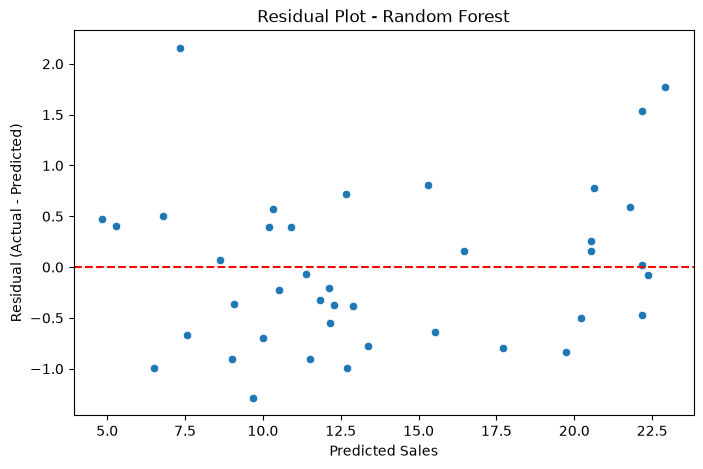

In [12]:
# Change this to whichever model scored best above (lowest RMSE, highest R2)
best_preds = rf_results['preds']
best_name = 'Random Forest'

residuals = y_test - best_preds

plt.figure(figsize=(8,5))
sns.scatterplot(x=best_preds, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Sales')
plt.ylabel('Residual (Actual - Predicted)')
plt.title(f'Residual Plot - {best_name}')
plt.show()

**Interpretation:** If the points scatter randomly around the zero line with no clear pattern, the model's errors are unsystematic and it's capturing the relationship well. If you see a curve, funnel shape, or any clear pattern, that signals the model is missing some structure in the data (e.g. a non-linear relationship it isn't capturing).

## Step 9: Which Advertising Channel Has the Highest Impact on Sales?

Linear Regression coefficients:
radio        0.189195
TV           0.044730
newspaper    0.002761
dtype: float64

Random Forest feature importances:
TV           0.624810
radio        0.362214
newspaper    0.012976
dtype: float64


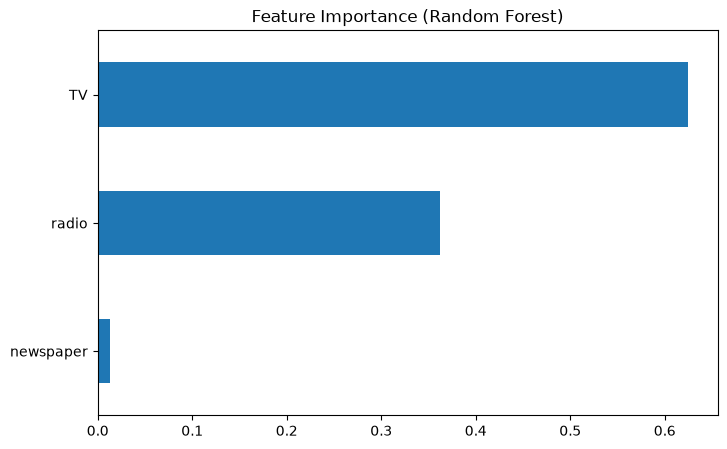

In [13]:
# Linear Regression coefficients - larger absolute value = bigger effect on Sales per unit of spend
coef_df = pd.Series(lr.coef_, index=X.columns).sort_values(ascending=False)
print('Linear Regression coefficients:')
print(coef_df)

# Random Forest feature importances - larger value = more influence on the model's predictions
importance_df = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print('\nRandom Forest feature importances:')
print(importance_df)

plt.figure(figsize=(8,5))
importance_df.plot(kind='barh')
plt.title('Feature Importance (Random Forest)')
plt.gca().invert_yaxis()
plt.show()

**Interpretation:** Compare the coefficients and feature importances above. In the classic version of this dataset, TV spend typically shows the strongest relationship with Sales, Radio has a moderate effect, and Newspaper has the weakest and least reliable effect. State your own dataset's actual result here once you've run the notebook - this is the key business takeaway of the whole project (e.g. "budget should be prioritized toward TV advertising over Newspaper").

## Conclusion

_Fill this in after running the notebook: which model performed better (Linear Regression vs Random Forest), its MAE/RMSE/R2 scores, whether the residual plot showed a random or systematic pattern, and which channel had the highest impact on Sales._